# **Importing Libraries**

In [1]:
import pandas as pd

# **Loading the training data**

In [2]:
df=pd.read_csv('/kaggle/input/playground-series-s6e1/train.csv')
print("Top 5 rows")
print(df.head())
print("\n")
print("Bottom 5 rows")
print(df.tail())

Top 5 rows
   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc         7.91              98.8              no   
1   1   18   other  diploma         4.95              94.8             yes   
2   2   20  female     b.sc         4.68              92.6             yes   
3   3   19    male     b.sc         2.00              49.5             yes   
4   4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          4.9       average  online videos             low            easy   
1          4.7          poor     self-study          medium        moderate   
2          5.8          poor       coaching            high        moderate   
3          8.3       average    group study            high        moderate   
4          9.6          good     self-study            high            easy   

   exam_score  
0        78.3  
1        46.7

# **Exploratory Data Analysis**

In [3]:
print(df.info())
print("\n")
print("Number of rows & Columns:",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB
None


Number of rows & Columns: (630000, 13)


# **Numeric & Non-Numeric Features**

In [4]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Non-numeric columns:", non_numeric_cols)

Numeric columns: ['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']
Non-numeric columns: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


# **Checking Missing values**

In [5]:
import numpy as np
missing_values = [None, np.nan, '', ' ', '?']
def check_missing(col):
    return col.isin(missing_values)
missing_summary = df.apply(lambda x: check_missing(x).sum())
print("Missing values summary per column:")
print(missing_summary)
rows_with_missing = df[df.apply(lambda x: check_missing(x)).any(axis=1)]
print("\nRows with missing values:")
print(rows_with_missing)
# Delete rows that contain ANY missing value
df = df[~df.apply(lambda x: check_missing(x)).any(axis=1)]
# Reset index (recommended)
df = df.reset_index(drop=True)
print("\nDataFrame after deleting rows with missing values:")
print(df)



Missing values summary per column:
id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

Rows with missing values:
Empty DataFrame
Columns: [id, age, gender, course, study_hours, class_attendance, internet_access, sleep_hours, sleep_quality, study_method, facility_rating, exam_difficulty, exam_score]
Index: []

DataFrame after deleting rows with missing values:
            id  age  gender   course  study_hours  class_attendance  \
0            0   21  female     b.sc         7.91              98.8   
1            1   18   other  diploma         4.95              94.8   
2            2   20  female     b.sc         4.68              92.6   
3            3   19    male     b.sc         2.00              49.5   
4            4   23    male      bc

In [6]:
duplicates = df.duplicated()
print("Duplicated rows (True indicates duplicate):")
duplicate_counts = duplicates.value_counts()
print("Count of duplicates (True = duplicate, False = unique):")
print(duplicate_counts)
print("\nDuplicated row details:")
print(df[duplicates])
df_cleaned = df.drop_duplicates()
print("\nDataFrame after dropping duplicates:")
print(df_cleaned)

Duplicated rows (True indicates duplicate):
Count of duplicates (True = duplicate, False = unique):
False    630000
Name: count, dtype: int64

Duplicated row details:
Empty DataFrame
Columns: [id, age, gender, course, study_hours, class_attendance, internet_access, sleep_hours, sleep_quality, study_method, facility_rating, exam_difficulty, exam_score]
Index: []

DataFrame after dropping duplicates:
            id  age  gender   course  study_hours  class_attendance  \
0            0   21  female     b.sc         7.91              98.8   
1            1   18   other  diploma         4.95              94.8   
2            2   20  female     b.sc         4.68              92.6   
3            3   19    male     b.sc         2.00              49.5   
4            4   23    male      bca         7.65              86.9   
...        ...  ...     ...      ...          ...               ...   
629995  629995   18  female   b.tech         4.86              70.7   
629996  629996   21  female   

**There is no missing and no duplicated rows in the training data**

# **Summary Statistics of training data**

In [7]:
import pandas as pd
print(df.describe())


                  id            age    study_hours  class_attendance  \
count  630000.000000  630000.000000  630000.000000     630000.000000   
mean   314999.500000      20.545821       4.002337         71.987261   
std    181865.479132       2.260238       2.359880         17.430098   
min         0.000000      17.000000       0.080000         40.600000   
25%    157499.750000      19.000000       1.970000         57.000000   
50%    314999.500000      21.000000       4.000000         72.600000   
75%    472499.250000      23.000000       6.050000         87.200000   
max    629999.000000      24.000000       7.910000         99.400000   

         sleep_hours     exam_score  
count  630000.000000  630000.000000  
mean        7.072758      62.506672  
std         1.744811      18.916884  
min         4.100000      19.599000  
25%         5.600000      48.800000  
50%         7.100000      62.600000  
75%         8.600000      76.300000  
max         9.900000     100.000000  


# **Distribution of Numerical Features**

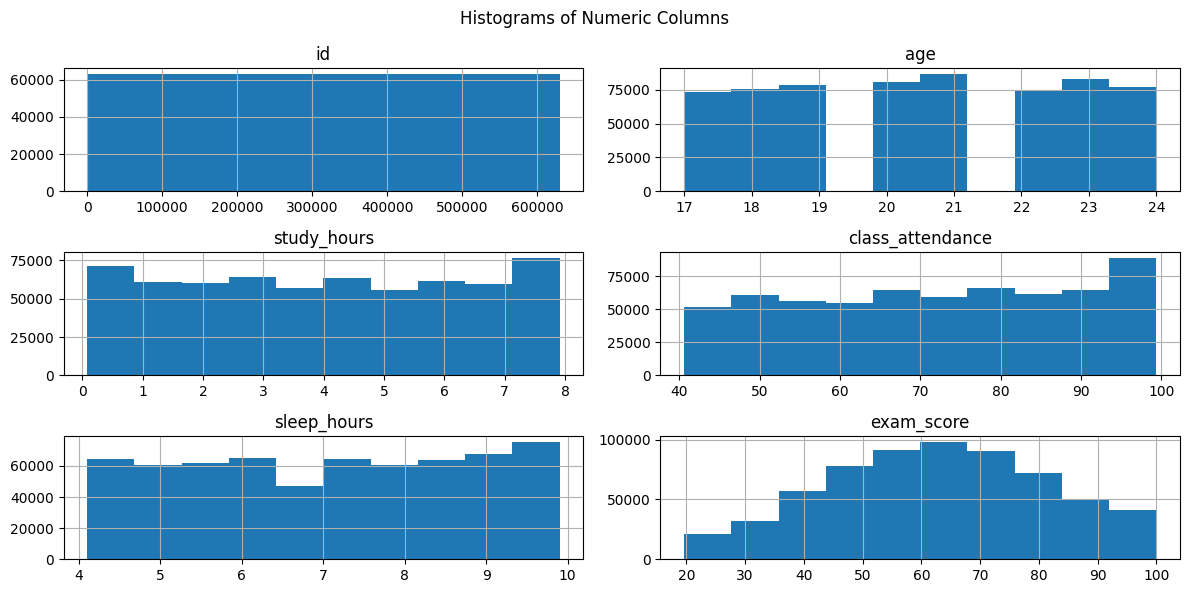

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Histograms for all numeric columns
df[numeric_cols].hist(figsize=(12, 6), bins=10)
plt.suptitle("Histograms of Numeric Columns")
plt.tight_layout()
plt.show()

# **Distribution of Non-Numerical/ Categorical Features**

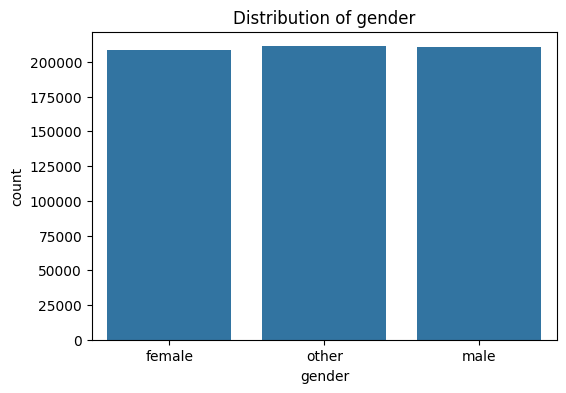

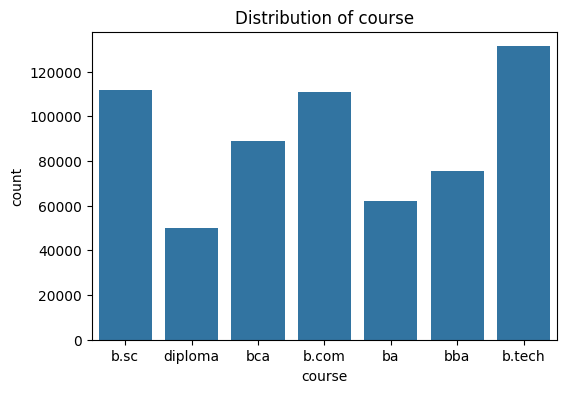

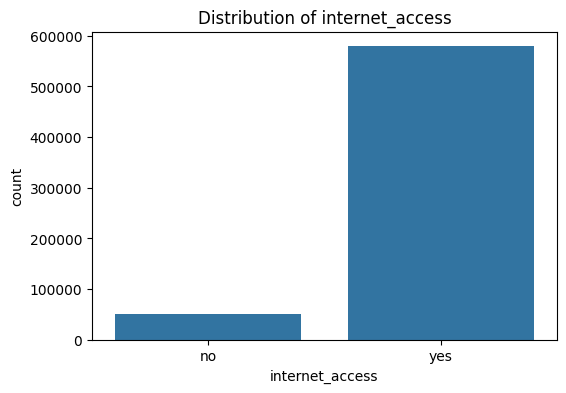

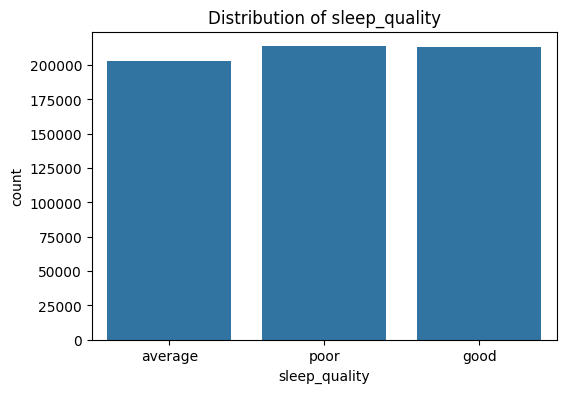

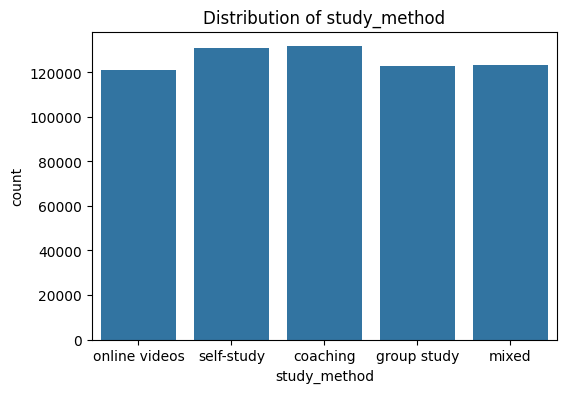

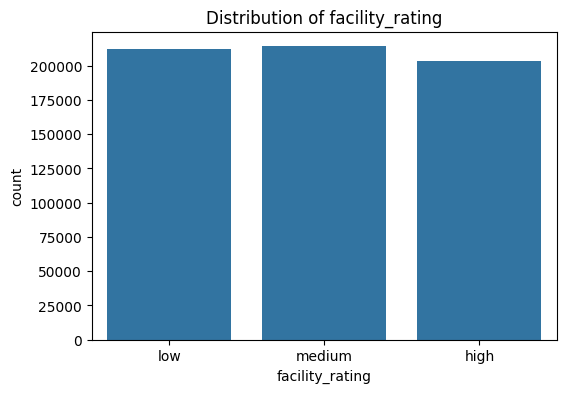

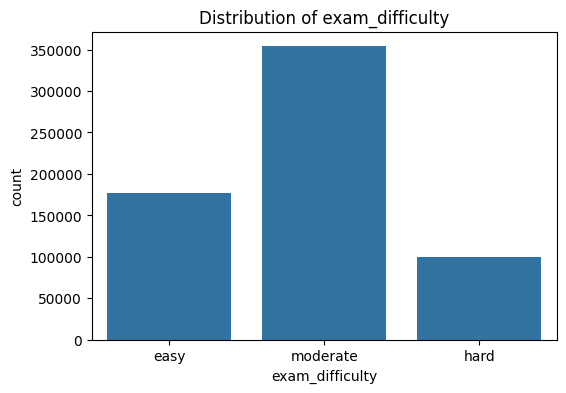

In [9]:
for col in non_numeric_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


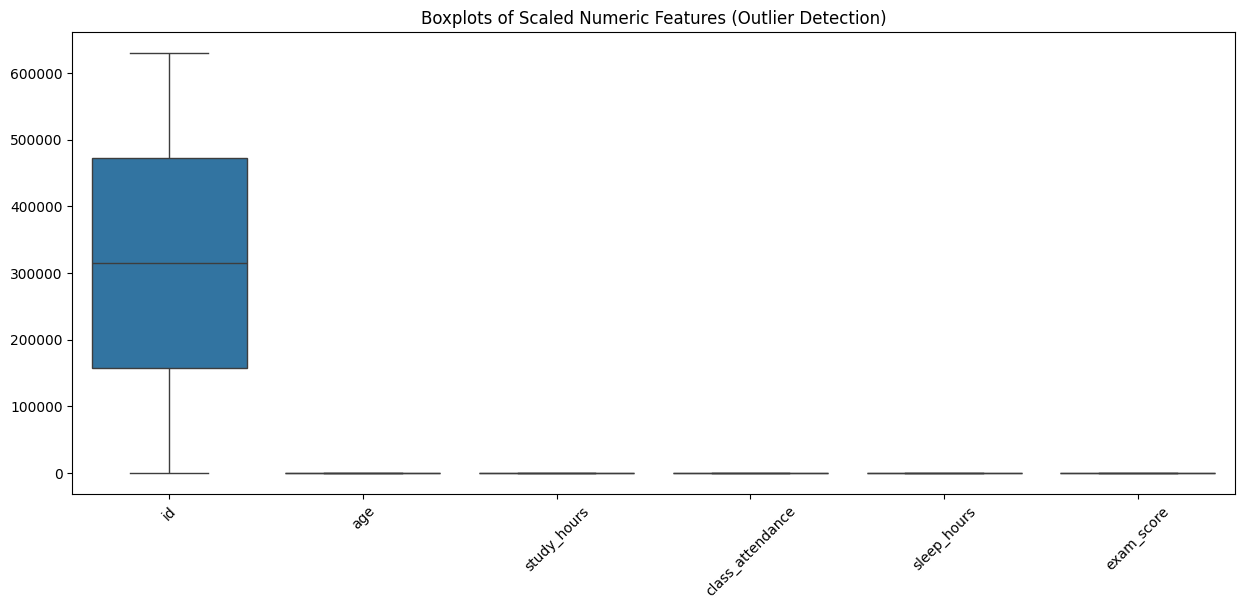

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots for all scaled numeric columns
plt.figure(figsize=(15, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Boxplots of Scaled Numeric Features (Outlier Detection)")
plt.xticks(rotation=45)
plt.show()


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
numeric_cols= ['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours']
non_numeric_cols= ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
# Copy dataframe
df_train = df.copy()
# Encode categorical columns
le_dict = {}  # store LabelEncoders to use for test
for col in non_numeric_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    le_dict[col] = le




# **Split features and target**

In [12]:
# Split features and target
X = df_train[numeric_cols + non_numeric_cols]
y = df_train['exam_score']

# **Splitting train and test (80/20)**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)


Training features shape: (504000, 12)
Testing features shape: (126000, 12)


# **RandomForest Regressor**

In [14]:
from sklearn.ensemble import RandomForestRegressor
# Initialize model
model = RandomForestRegressor(n_estimators=100, random_state=42)
# Train
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

# **Evaluation metrics**

Mean Absolute Error (MAE): 7.242772932619047
Mean Squared Error (MSE): 82.67761625012125
Root Mean Squared Error (RMSE): 9.092723258195052
R² Score: 0.76752909465196


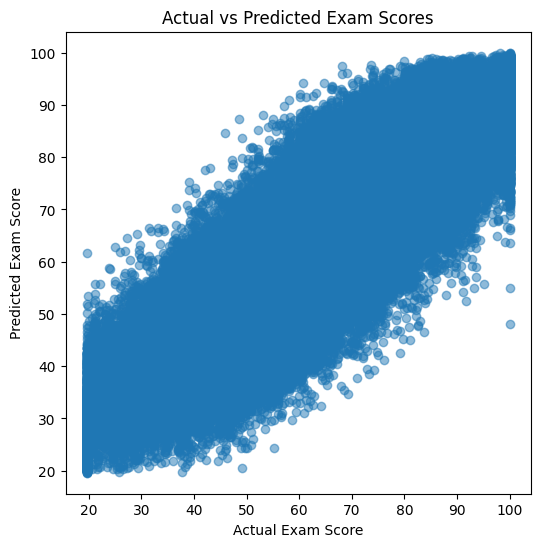

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
# Predict
y_pred = model.predict(X_test)
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Optional: visualize actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

# **Loading test.csv**

In [16]:
import pandas as pd
test_df = pd.read_csv('/kaggle/input/playground-series-s6e1/test.csv')
print(test_df.head(10))
print(test_df.columns)

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba         6.85              65.2   
1  630001   18    male  diploma         6.61              45.0   
2  630002   24  female   b.tech         6.60              98.5   
3  630003   24    male  diploma         3.03              66.3   
4  630004   20  female   b.tech         2.03              42.4   
5  630005   21    male     b.sc         6.22              55.3   
6  630006   22   other       ba         3.59              91.6   
7  630007   20    male     b.sc         3.14              82.7   
8  630008   18    male  diploma         6.49              86.0   
9  630009   23  female   b.tech         7.72              95.8   

  internet_access  sleep_hours sleep_quality   study_method facility_rating  \
0             yes          5.2          poor    group study            high   
1              no          9.3          poor       coaching             low   
2             yes          6.2      

# **Label Encoding**

In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
numeric_cols_test= ['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours']
non_numeric_cols_test= ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
# Copy dataframe
df_test = test_df.copy()
# Encode categorical columns
le_dict = {}  # store LabelEncoders to use for test
for col in non_numeric_cols_test:
    le = LabelEncoder()
    df_test[col] = le.fit_transform(df_test[col].astype(str))
    le_dict[col] = le

# **Predicting test score**

In [18]:

X_test = df_test[numeric_cols_test + non_numeric_cols_test]
# Predict
y_pred = model.predict(X_test)
# Save predictions
output = pd.DataFrame({
    'id': test_df['id'],  # must be same length as X_test
    'exam_score': y_pred
})
print(output.head())
output.to_csv('/kaggle/working/submission.csv', index=False)
print("Predictions saved successfully!")
print(X_test.columns)

       id  exam_score
0  630000      68.719
1  630001      73.405
2  630002      84.055
3  630003      51.410
4  630004      46.531
Predictions saved successfully!
Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours', 'gender',
       'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


In [19]:
import joblib
joblib.dump(model, "student_performance_model.pkl")

['student_performance_model.pkl']